In [84]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, make_interp_spline
import numpy as np
from pathlib import Path
sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size

import scipy.stats as st

# Analyse CFUs from chemostat experiments

In [3]:

repo_folder = Path("../..")

data_folder = repo_folder / "data/4_chemostats/"
figure_folder = repo_folder / 'figures' / '4_chemostats'
figure_folder.mkdir(exist_ok = True)
df_cfu = pd.read_csv(data_folder / "cfus.csv")

In [4]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [5]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [6]:
df_cfu.rename(columns={'reactor':'Carbon source', 'average': 'Mean CFUs/mL', 'stdev': 'Std. CFUs/mL', 'sample_time': 'Time [h]',
                       'species':'Species'}, inplace=True)


In [7]:
df_cfu['Species'] = df_cfu['Species'].str.capitalize()
df_cfu.replace({'Species':{'Ms':'Ml'}}, inplace=True)

In [8]:
df_cfu = pd.concat([df_cfu, df_cfu['count'].str.split('|', expand=True).rename(columns={0:'A', 1:'B', 2:'C'}).apply(lambda x: x.str.strip())], axis=1)

In [9]:
# Calculate CFUs/mL for each replicate
drop_volume = 5*1e-3  # 5 microliters in mL
for i, row in df_cfu.iterrows():
    for rep in 'ABC':
        df_cfu.at[i, f'{rep} CFUs/mL'] = (float(row[rep]) / drop_volume) * np.power(10.0, -row['dilution']) 
# df_cfu['Average 2 CFUs/mL'] = df_cfu[['A CFUs/mL', 'B CFUs/mL', 'C CFUs/mL']].mean(axis=1)

In [10]:
df_cfuL = df_cfu.melt(id_vars=['Carbon source', 'Species', 'Time [h]'], value_vars=['A CFUs/mL', 'B CFUs/mL', 'C CFUs/mL'],
                       var_name='Replicate', value_name='CFUs/mL') 

In [11]:
df_cfuL['Replicate'] = df_cfuL['Replicate'].str.replace(' CFUs/mL', '', regex=False)
df_cfuL['Carbon source'] = df_cfuL['Carbon source'].str.capitalize()

In [12]:
df_cfuL.replace({'Carbon source':{'Glutaric acid':'Glutarate'}}, inplace=True)

# Plot

In [13]:
df_cfuL['Time [h] rounded'] = df_cfuL['Time [h]'].round(1).astype(int)

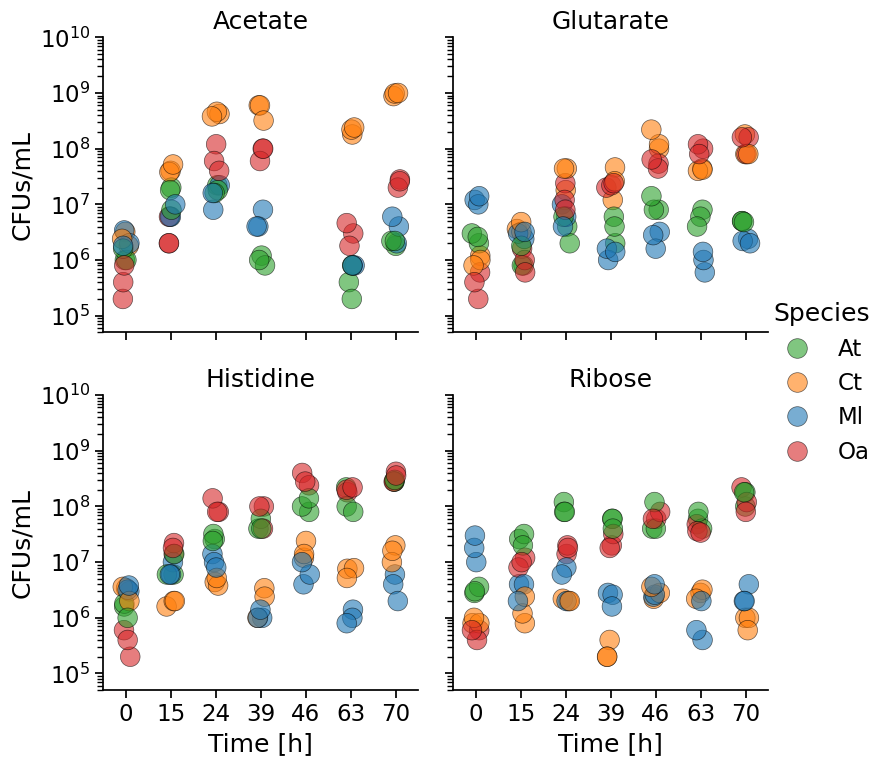

In [14]:
ncols = 2
# Create the catplot
g = sns.catplot(
    data=df_cfuL,
    x='Time [h] rounded',
    y='CFUs/mL',
    hue='Species',
    col='Carbon source',
    col_wrap=ncols,
    # col_order=col_order,
    log_scale=True,
    sharey=True,
    kind='strip',
    palette=palette,
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    s=200,
    alpha=0.6,
    sharex=True,
    height=4,
    edgecolor='k',
    linewidth=0.5,
    col_order=['Acetate', 'Glutarate', 'Histidine', 'Ribose']
)
plt.ylim(5e4, 1e10)
# Set titles without "Carbon source = "
g.set_titles("{col_name}")
# g = sns.catplot(data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain', col = 'Carbon source', col_wrap=4, log_scale = True, sharey=True, kind = 'strip', palette = palette, 
#                 hue_order=['At', 'Ct', 'Ml', 'Oa'], s = 200, alpha = 0.5, sharex=True, height = 4, edgecolor = 'k', linewidth = 0.5)
g.set_axis_labels('Time [h]')
# # g.map_dataframe(sns.lineplot, data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain',  hue_order=['At', 'Ct', 'Ml', 'Oa'], palette = palette, errorbar = None)
# g.set_titles("{col_name}")
plt.savefig(figure_folder / 'coexistence_chemostat.pdf')
plt.show()

# Compare with assembly experiment 1

In [15]:
assembly_1_folder = Path("../../data/2_first_community_assembly")
df_mean78 = pd.read_csv(assembly_1_folder / "df_mean78.csv", index_col=0)

In [20]:
df_cmean = df_cfuL.loc[df_cfuL['Time [h] rounded'] > 41].groupby(['Carbon source', 'Species'])['CFUs/mL'].agg(['mean', 'std']).reset_index()

In [24]:
both_df = pd.merge(left=df_mean78[['Species', 'Carbon source', 'Mean CFUs/mL', 'Std CFUs/mL']], right = df_cmean, on = ['Species', 'Carbon source'], suffixes=('_assembly', '_chemostat'))

In [25]:
both_df.columns = ['Species', 'Carbon source', 'Mean CFUs/mL transfer', 'Std CFUs/mL transfer', 'Mean CFUs/mL chemostat', 'Std CFUs/mL chemostat']

In [41]:
cs_to_style = {'Acetate': 'o', 'Glutarate': 's', 'Histidine': 'D', 'Ribose': '^'}

In [87]:
both_df['log10 transfer'] = np.log10(both_df['Mean CFUs/mL transfer'])
both_df['log10 chemostat'] = np.log10(both_df['Mean CFUs/mL chemostat'])

rho, pval = st.pearsonr(both_df['log10 transfer'], both_df['log10 chemostat'])

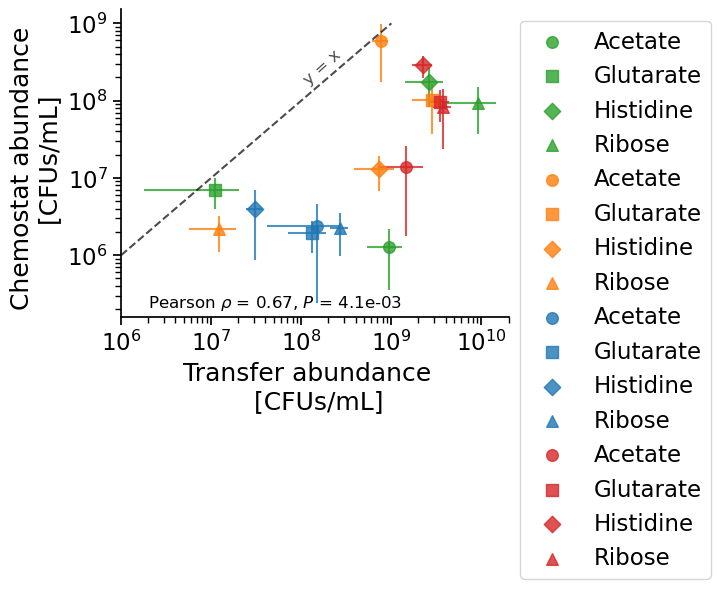

In [97]:
fig, ax = plt.subplots(figsize=(5,4))
# sns.scatterplot(data=both_df, x='Mean CFUs/mL transfer', y='Mean CFUs/mL chemostat', hue='Species', style='Carbon source', palette=palette, s=200, edgecolor='k', linewidth=0.5)
for i, row in both_df.iterrows():
    x = row['Mean CFUs/mL transfer']
    y = row['Mean CFUs/mL chemostat']
    x_std = row['Std CFUs/mL transfer']
    y_std = row['Std CFUs/mL chemostat']
    cs = row['Carbon source']
    sp = row['Species']
    j = strains.index(sp)
    ax.scatter(x, y, color = palette[j], marker = cs_to_style[cs],  linewidth=1, s = 70, alpha = 0.8, label = cs, zorder = 2)#, edgecolor='k', zorder = 10)
    ax.errorbar(x, y, xerr = x_std, yerr = y_std, color = palette[j], alpha = 0.8, markersize = 0, zorder = 1)
ax.plot([1e6, 1e9], [1e6, 1e9], 'k--', alpha = 0.7)
ax.set_xlim(1e6, 2e10)
plt.xscale('log')
plt.yscale('log')
plt.text(1e8, 1.5e8, 'y = x', fontsize=12, color='k', alpha=0.7, rotation=42, va='bottom', ha='left')
plt.text(2e6, 1.8e5, fr'Pearson $\rho$ = {rho:.2f}, $P$ = {pval:.1e}', fontsize=12, color='k', va='bottom', ha='left')
plt.xlabel('Transfer abundance  \n [CFUs/mL]')
plt.ylabel('Chemostat abundance \n [CFUs/mL]')
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
sns.despine()
plt.savefig(figure_folder / 'assembly_chemostat_comparison.pdf', bbox_inches='tight')
# sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))

PearsonRResult(statistic=np.float64(0.6749619276327752), pvalue=np.float64(0.004122174393216163))

In [86]:
st.spearmanr(both_df['log10 transfer'], both_df['log10 chemostat'])

SignificanceResult(statistic=np.float64(0.6205882352941177), pvalue=np.float64(0.010313515549677674))

# Rate lag trade off

In [14]:

gp_folder = repo_folder / 'data/1_growth_phenotyping'

rate_df = pd.read_csv(gp_folder / 'fitted_growth_parameters.csv', index_col=0)
rate_df['Carbon source'] = rate_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
rate_df['# CS'] = 1
rate_df.loc[rate_df['Carbon source'] == 'No cs', '# CS'] = 0
rate_df.replace({'max_growth_rate':{np.nan:0}}, inplace=True)



In [16]:
species_list = ['At', 'Ct', 'Ml', 'Oa']

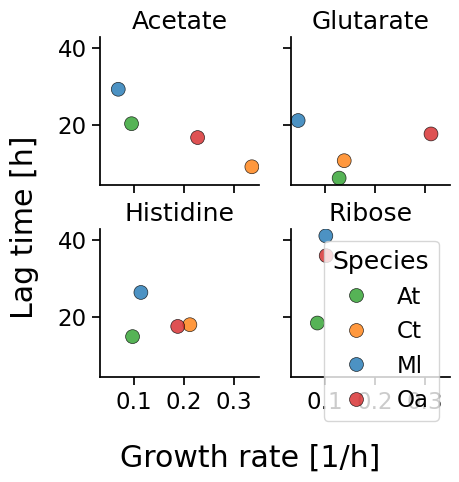

In [20]:
four_cs = ['Acetate', 'Glutarate', 'Histidine', 'Ribose']
fig, axes = plt.subplots(2,2, figsize = (5,5), sharex=True, sharey = True)
axes = axes.flatten()
for i, cs in enumerate(four_cs):
    ax = axes[i]
    idxcs = rate_df['Carbon source'] == cs
    if i == 3:
        legend=True
    else:
        legend = False
    ax.set_title(cs)
    sns.scatterplot(rate_df.loc[idxcs], x = 'max_growth_rate', y = 'lag', ax = ax, hue = 'Species',
                    s = 100,
                    alpha = 0.8,
                    edgecolor='k',
                    linewidth=0.5,
                    palette = palette, hue_order = species_list, legend = legend)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.supxlabel('Growth rate [1/h]')
fig.supylabel('Lag time [h]')
plt.subplots_adjust(left = 0.2, bottom=0.2, hspace = 0.3, wspace=0.2)
sns.despine()
# plt.savefig()